# Exploration of datasets
## PAN 2023

In [64]:
import os, sys
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.detectors.impostor import ImpostorDetector

In [65]:
ds_pan = load_from_disk(os.path.join(os.path.abspath(".."), CONFIG.PATH2PAN23))['train'].to_pandas()
labels = ds_pan['same']
display(ds_pan.head())

,id,discourse_types,pair,same,authors
0,a0e656a3-955e-44f6-b5b3-dfd6e360a962,"[email, speech_transcription]",[I think I have decided with regards to the <t...,True,"[en_7, en_7]"
1,c42efa75-f418-4fac-80ca-4d0982704d25,"[email, speech_transcription]","[Dear <addr10_NN>, <nl><nl>If I was to go with...",True,"[en_31, en_31]"
2,a3a6745f-af62-4889-af49-93ec88594142,"[interview, email]","[So, erm, so I’m, erm, I’m actually from <cou...",True,"[en_88, en_88]"
3,244235f3-4647-4ed3-b078-60a2ea2850b7,"[email, speech_transcription]","[Hi <addr2_FN><nl><nl>This is my picture, that...",False,"[en_27, en_38]"
4,d410b3f0-b331-48ab-a524-c29ed1d487a2,"[interview, email]","[Oh, okay. Erm, well, I think of myself as kin...",False,"[en_87, en_32]"


In [66]:
labels.value_counts()

same
True     4418
False    4418
Name: count, dtype: int64

In [67]:



pairs = ds_pan['pair'].tolist()
pairs = [s for item in pairs for s in item.flatten().tolist() if isinstance(item, np.ndarray)]
#pairs

In [68]:


def plot_text_length_histogram(text_list, bins=10, preprocessed:bool = False):
    """
    Plots a histogram of text lengths (in characters) for a list of strings.

    Args:
        text_list (list): List of strings.
        bins (int): Number of bins in the histogram.
    """
    lengths = [len(text) for text in text_list]
    unit = 'characters' if type(lengths[0]) is str else 'ngrams'
    
    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=bins, color='skyblue', edgecolor='black')
    title = 'Histogram of Text Lengths (Stemmed)' if preprocessed else 'Histogram of Text Lengths'
    plt.title(title)
    plt.xlabel(f'Text Length ({unit})')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

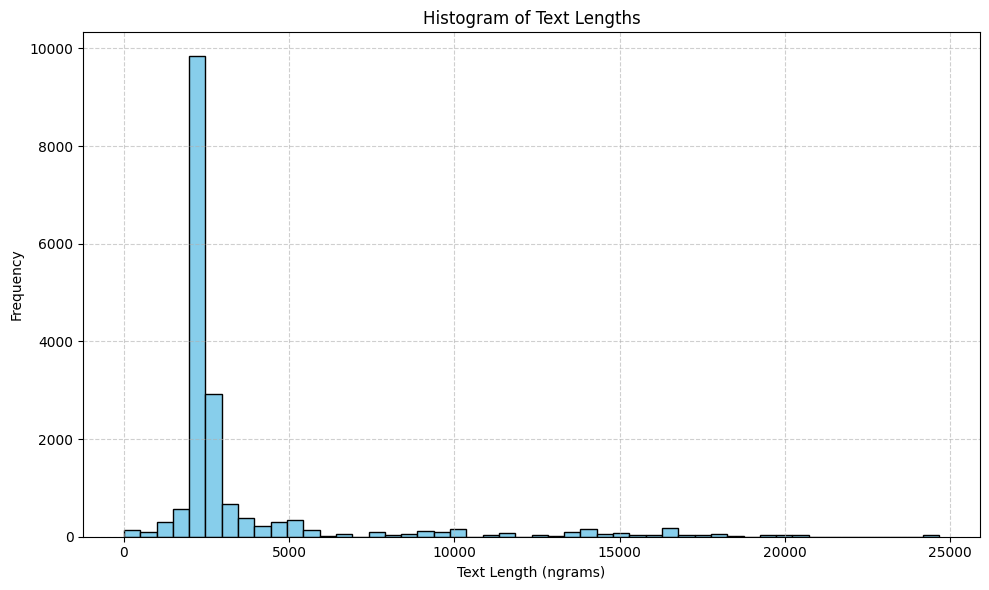

In [ ]:
plot_text_length_histogram(pairs, bins=50)
avg_len = np.mean([len(text) for text in pairs])
print(f"Average length (characters) per text: {avg_len:.2f}")

In [70]:
def normalize_text(text):
    stemmer = SnowballStemmer('english')
    return ' '.join(stemmer.stem(w) for w in text.lower().split())

In [71]:
# plot_text_length_histogram([normalize_text(p) for p in pairs], bins=50, preprocessed=True)

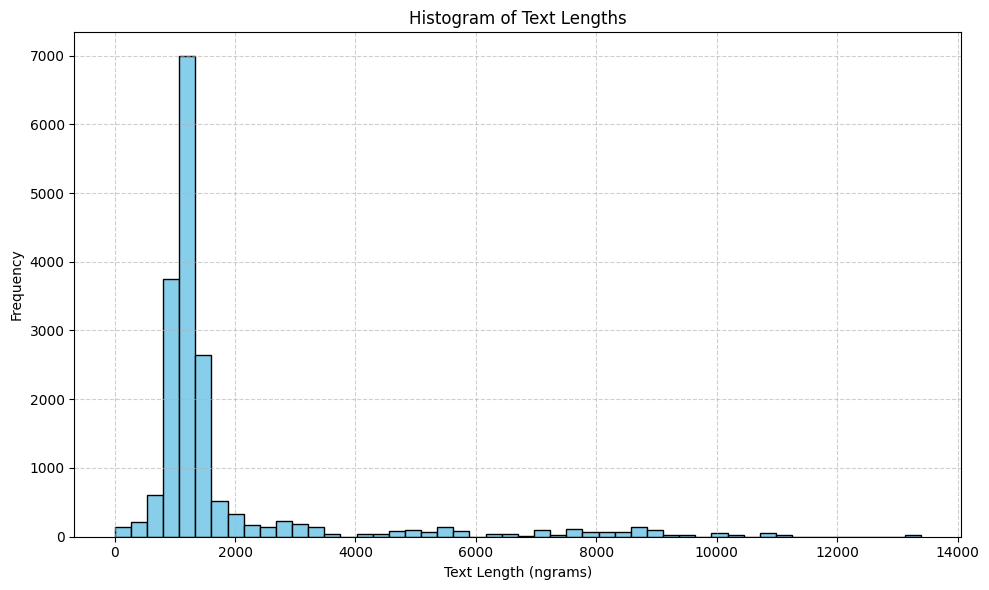

Average number of 4-grams per pair: 1815.37


In [73]:
impostor_det = ImpostorDetector(ds_pan, top_n=250, portion_delete=0.5, shared_vocab_only=True, strict=True)
# list of lists of 4-grams
four_grams = [impostor_det.tokenize_char_ngrams(p, n=4, normalize_ws=True, space_free=True) for p in pairs]
plot_text_length_histogram(four_grams, bins=50, preprocessed=False)
avg_n_four_grams = np.mean([len(ng) for ng in four_grams])
print(f"Average number of 4-grams per text: {avg_n_four_grams:.2f}")